# Domain closeness

Given a variant and a threshold (in %), count how many entries have their **second closest domain within `threshold%` of the closest**.

Source data: the domain neighbours file produced by `tools/classify.py`, which stores for each domain the top-10000 entries and their similarity scores:

`data/semantic_search/<VARIANT>/semantic_search-edition_7-doc2vec-learn-mc_40-ng_1-tm_0.5-ch_sentence.tv2_domains.json`

An entry absent from a domain's list has a score of 0 for that domain (see `helpers/classifiers/semantic_search.py`, `classify`). The metric is **relative**: an entry is counted when `closest > 0` and `second >= closest * (1 - threshold/100)`.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

sys.path.append(str(Path.cwd().parent))
from helpers import settings

VARIANT = '2026-07-19'
THRESHOLD = 5

DOMAIN_NEIGHBOURS_FILENAME = 'semantic_search-edition_7-doc2vec-learn-mc_40-ng_1-tm_0.5-ch_sentence.tv2_domains.json'

domain_neighbours_path = Path(settings.DATA_PATH, 'semantic_search', VARIANT, DOMAIN_NEIGHBOURS_FILENAME)
if not domain_neighbours_path.exists():
    raise FileNotFoundError(f'No domain neighbours file found for variant "{VARIANT}" at {domain_neighbours_path}')

domain_results = json.loads(domain_neighbours_path.read_text())

print(f'Variant: {VARIANT}')
print(f'Threshold: {THRESHOLD}%')
print(f'Domains: {list(domain_results.keys())}')
print(f'Entries per domain list: {[len(r["aids"]) for r in domain_results.values()]}')

Variant: 2026-07-19
Threshold: 5%
Domains: ['sacred_history', 'civil_history', 'natural_history', 'useful_arts', 'theology', 'philosophy', 'natural_science', 'fine_arts']
Entries per domain list: [10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000]


## Build the entry x domain score map

Each domain records its top-10000 entries with their similarity scores. An entry that does not appear in a domain's list has an implicit score of 0 for that domain. We gather, for every entry that appears in at least one list, its non-zero score per domain.

In [2]:
entry_scores = {}
for domain, results in domain_results.items():
    for aid, score in zip(results['aids'], results['scores']):
        entry_scores.setdefault(aid, {})[domain] = score

print(f'Entries present in at least one domain list: {len(entry_scores)}')

Entries present in at least one domain list: 20507


## Compute closest vs second closest domain

For each entry we sort its domain scores descending. `closest` is the highest score, `second` the next one (0 if the entry appears in only one domain list). An entry is **within the threshold** when `closest > 0` and `second >= closest * (1 - threshold/100)`.

In [3]:
rows = []
factor = 1 - THRESHOLD / 100
for aid, scores in entry_scores.items():
    ordered = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
    closest_domain, closest_score = ordered[0]
    second_domain, second_score = ordered[1] if len(ordered) > 1 else (None, 0.0)
    ratio = second_score / closest_score if closest_score > 0 else 0.0
    within_threshold = closest_score > 0 and second_score >= closest_score * factor
    rows.append({
        'aid': aid,
        'closest_domain': closest_domain,
        'closest_score': closest_score,
        'second_domain': second_domain,
        'second_score': second_score,
        'ratio': ratio,
        'within_threshold': within_threshold,
    })

df = pd.DataFrame(rows).set_index('aid')
df.head()

,closest_domain,closest_score,second_domain,second_score,ratio,within_threshold
aid,,,,,,
eb07/XML/s19/kp-eb0719-060202-0656.xml,sacred_history,0.730956,theology,0.245903,0.336413,False
eb07/XML/h11/kp-eb0711-012101-0668.xml,sacred_history,0.473483,philosophy,0.302745,0.639399,False
eb07/XML/h11/kp-eb0711-050804-5699.xml,sacred_history,0.460717,theology,0.204745,0.444407,False
eb07/XML/m15/kp-eb0715-000407-9261.xml,sacred_history,0.458326,theology,0.343147,0.748695,False
eb07/XML/p17/kp-eb0717-021811-3921.xml,sacred_history,0.456564,theology,0.294324,0.644650,False


## Result

Number and percentage of entries whose second closest domain is within the threshold of the closest.

In [4]:
total = len(df)
count = int(df['within_threshold'].sum())
percentage = count / total * 100 if total else 0

print(f'{count} of {total} entries ({percentage:.1f}%) have their second closest domain within {THRESHOLD}% of the closest')

2024 of 20507 entries (9.9%) have their second closest domain within 5% of the closest


## Enrich with entry titles

Load the variant index (edition 7 only) and merge titles to inspect the flagged entries.

In [5]:
index_path = Path(settings.DATA_PATH, VARIANT, 'index.json')
index = pd.read_json(index_path, orient='table')
index = index[index['edition'] != 9][['title']]

flagged = df[df['within_threshold']].join(index, how='inner')
flagged = flagged[['title', 'closest_domain', 'closest_score', 'second_domain', 'second_score', 'ratio']]
flagged.sort_values('ratio', ascending=False).head(20)

,title,closest_domain,closest_score,second_domain,second_score,ratio
eb07/XML/d8/kp-eb0708-003602-3603.xml,DIOPHANTUS,civil_history,0.173740,philosophy,0.173740,1.000000
eb07/XML/c6/kp-eb0706-005208-7679.xml,CAMPUS,sacred_history,0.162497,fine_arts,0.162492,0.999975
eb07/XML/a2/kp-eb0702-038602-4827.xml,ALCALA de Guadeira,sacred_history,0.157349,useful_arts,0.157345,0.999971
eb07/XML/c6/kp-eb0706-012701-8654.xml,CAPPANUS,useful_arts,0.262121,natural_science,0.262112,0.999967
eb07/XML/j12/kp-eb0712-065703-6343.xml,JUTLAND,natural_history,0.169923,natural_science,0.169916,0.999955
eb07/XML/f9/kp-eb0709-060902-3175.xml,FISHING,useful_arts,0.206340,natural_science,0.206307,0.999840
eb07/XML/m15/kp-eb0715-041304-4578.xml,"MONGE, Gaspar",civil_history,0.154132,natural_science,0.154106,0.999828
eb07/XML/s20/kp-eb0720-072103-0867.xml,STEREOGRAPHIC Projection,useful_arts,0.191043,natural_history,0.191008,0.999819
eb07/XML/m14/kp-eb0714-031206-3878.xml,MASULI,natural_history,0.204016,useful_arts,0.203967,0.999759
eb07/XML/a2/kp-eb0702-019607-2357.xml,AES uxorium,sacred_history,0.153855,philosophy,0.153816,0.999741


## Breakdown by closest domain

How the flagged entries distribute across their closest domain.

In [6]:
breakdown = flagged.groupby('closest_domain').size().sort_values(ascending=False)
breakdown

closest_domain
useful_arts        334
natural_science    312
sacred_history     305
natural_history    301
philosophy         255
theology           184
civil_history      178
fine_arts          155
dtype: int64

## Distribution of second/closest ratios

Histogram of the ratio of the second closest score over the closest score, with the threshold line at `1 - threshold/100`.

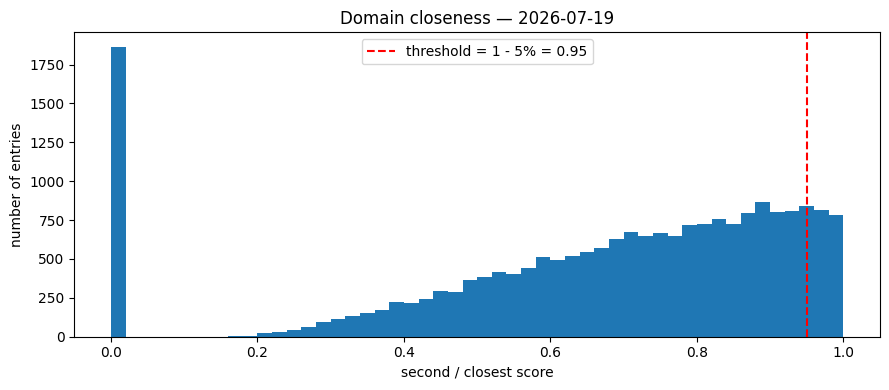

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['ratio'], bins=50)
ax.axvline(factor, color='red', linestyle='--', label=f'threshold = 1 - {THRESHOLD}% = {factor:.2f}')
ax.set_xlabel('second / closest score')
ax.set_ylabel('number of entries')
ax.set_title(f'Domain closeness — {VARIANT}')
ax.legend()
plt.tight_layout()
plt.show()